#Cleaning, handeling and orginazing

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('high_popularity_spotify_data.csv')
df.head()
#In our Data the same song will appear multiple times if it is featured in different playlists

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3,0.0304,...,0.0000,10FLjwfpbxLmW8c25Xyc2N,0,6,251668,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4,0.0358,...,0.0608,7aJuG4TFXa2hmE4z1yxc3n,1,2,210373,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4,0.0368,...,0.0000,0hBRqPYPXhr1RkTDG3n4Mk,1,1,166300,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
3,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,4,0.0634,...,0.0000,4B4Elma4nNDUyl6D5PvQkj,0,0,157280,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
4,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4,0.2600,...,0.0000,2IYQwwgxgOIn7t3iF6ufFD,0,0,169917,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M


In [3]:
#Checking for missing data
missing_values = df.isnull().sum()
print(missing_values)

energy                      0
tempo                       0
danceability                0
playlist_genre              0
loudness                    0
liveness                    0
valence                     0
track_artist                0
time_signature              0
speechiness                 0
track_popularity            0
track_href                  0
uri                         0
track_album_name            1
playlist_name               0
analysis_url                0
track_id                    0
track_name                  0
track_album_release_date    0
instrumentalness            0
track_album_id              0
mode                        0
key                         0
duration_ms                 0
acousticness                0
id                          0
playlist_subgenre           0
type                        0
playlist_id                 0
dtype: int64


In [4]:
#Searching for rows with a missing value
specific_missing = df[df['track_album_name'].isnull()]
#Printing it
print(specific_missing)
df.columns

     energy    tempo  danceability playlist_genre  loudness  liveness  \
665   0.926  105.969         0.682          k-pop    -2.515      0.19   

     valence track_artist  time_signature  speechiness  ...  instrumentalness  \
665     0.86       NAYEON               4       0.0607  ...               0.0   

             track_album_id mode key duration_ms acousticness  \
665  5zQI9dFbS9TrhvC9clgjz7    0   3      162840       0.0404   

                         id playlist_subgenre            type  \
665  0V2passWyAXnON67kfAj7y            modern  audio_features   

                playlist_id  
665  1bNuDsel3P60p11Z7vfHMR  

[1 rows x 29 columns]


Index(['energy', 'tempo', 'danceability', 'playlist_genre', 'loudness',
       'liveness', 'valence', 'track_artist', 'time_signature', 'speechiness',
       'track_popularity', 'track_href', 'uri', 'track_album_name',
       'playlist_name', 'analysis_url', 'track_id', 'track_name',
       'track_album_release_date', 'instrumentalness', 'track_album_id',
       'mode', 'key', 'duration_ms', 'acousticness', 'id', 'playlist_subgenre',
       'type', 'playlist_id'],
      dtype='object')

In [5]:
#Checking for full dates
full_dates = df[df['track_album_release_date'].str.len() == 10]
print(full_dates['track_album_release_date'].head())

# Checking for rows where the date is only the year
years_only = df[df['track_album_release_date'].str.len() == 4]
print(years_only['track_album_release_date'])

0    2024-08-16
1    2024-05-17
2    2024-10-18
3    2024-08-23
4    2024-10-18
Name: track_album_release_date, dtype: object
58      1977
82      1992
84      1976
87      1982
96      1977
        ... 
1644    1998
1645    1996
1646    1985
1648    1996
1649    1997
Name: track_album_release_date, Length: 80, dtype: object


In [6]:
#DATE STANDARTIZATION
# Converting the column into the right date format
df['track_album_release_date'] = pd.to_datetime(df['track_album_release_date'], format='mixed')

# Extracting year, month and day
df['release_date'] = df['track_album_release_date'].dt.year
df.rename(columns={'release_date': 'release_year'}, inplace=True) #Changing the name
df['release_month'] = df['track_album_release_date'].dt.month
df['release_day'] = df['track_album_release_date'].dt.day

In [7]:
#Creating another data frame without the duplicate IDs for statistics and such
df_unique = df.drop_duplicates(subset=['track_id']).copy()

In [8]:
df_unique['track_id'].nunique()
df_unique.shape
df_unique.dtypes
df_unique.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1437 entries, 0 to 1685
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   energy                    1437 non-null   float64       
 1   tempo                     1437 non-null   float64       
 2   danceability              1437 non-null   float64       
 3   playlist_genre            1437 non-null   object        
 4   loudness                  1437 non-null   float64       
 5   liveness                  1437 non-null   float64       
 6   valence                   1437 non-null   float64       
 7   track_artist              1437 non-null   object        
 8   time_signature            1437 non-null   int64         
 9   speechiness               1437 non-null   float64       
 10  track_popularity          1437 non-null   int64         
 11  track_href                1437 non-null   object        
 12  uri                      

In [9]:
#Checking for redundancy
print(df['track_id'])
print(df['id'])

0       2plbrEY59IikOBgBGLjaoe
1       6dOtVTDdiauQNBQEDOtlAB
2       7ne4VBA60CxGM75vw0EYad
3       1d7Ptw3qYcfpdLNL5REhtJ
4       5vNRhkKd0yEAg8suGBpjeY
                 ...          
1681    26b3oVLrRUaaybJulow9kz
1682    1wADwLSkYhrSmy4vdy6BRn
1683    7vKXc90NT5WBm3UTT4iTVG
1684    59nOXPmaKlBfGMDeOVGrIK
1685    2GE3k8I0Sbh0puCjI15KGy
Name: track_id, Length: 1686, dtype: object
0       2plbrEY59IikOBgBGLjaoe
1       6dOtVTDdiauQNBQEDOtlAB
2       7ne4VBA60CxGM75vw0EYad
3       1d7Ptw3qYcfpdLNL5REhtJ
4       5vNRhkKd0yEAg8suGBpjeY
                 ...          
1681    26b3oVLrRUaaybJulow9kz
1682    1wADwLSkYhrSmy4vdy6BRn
1683    7vKXc90NT5WBm3UTT4iTVG
1684    59nOXPmaKlBfGMDeOVGrIK
1685    2GE3k8I0Sbh0puCjI15KGy
Name: id, Length: 1686, dtype: object


In [10]:
#Handling The NaN value in album name
df_unique['track_album_name'] = df_unique['track_album_name'].fillna('Unknown Album')

In [11]:
 #Handeling Redondent track_id and id
df_unique = df_unique.drop(columns=['id'])
print(list(df_unique.columns))

['energy', 'tempo', 'danceability', 'playlist_genre', 'loudness', 'liveness', 'valence', 'track_artist', 'time_signature', 'speechiness', 'track_popularity', 'track_href', 'uri', 'track_album_name', 'playlist_name', 'analysis_url', 'track_id', 'track_name', 'track_album_release_date', 'instrumentalness', 'track_album_id', 'mode', 'key', 'duration_ms', 'acousticness', 'playlist_subgenre', 'type', 'playlist_id', 'release_year', 'release_month', 'release_day']


In [12]:
from sklearn.preprocessing import StandardScaler

# Defining the columns we want to scale
features_to_scale = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'duration_ms'
]
scaler = StandardScaler()

# Creating a copy df for the machine learning aspects
ml_df = df_unique.copy()

# Scaling
ml_df[features_to_scale] = scaler.fit_transform(ml_df[features_to_scale])

<function matplotlib.pyplot.show(close=None, block=None)>

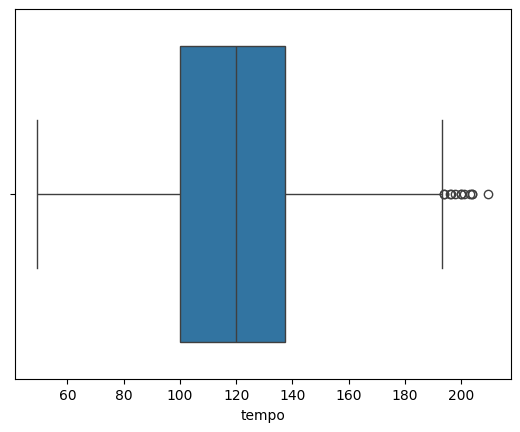

In [13]:
#Boxplot for outliers
sns.boxplot(x=df_unique['tempo'])
plt.show

In [14]:
#making the is pop column where only scores >= 90 get in
ml_df['is_pop_90'] = (ml_df['track_popularity'] >= 90).astype(int)
#Encoding the genre and release month columns to binary, without statistical duplicates
ml_df = pd.get_dummies(ml_df, columns=['playlist_genre', 'release_month'], drop_first=True)
#Checking Shape
print(ml_df.shape)

(1437, 68)


#Business Question 1: What does a typical highly popular track look like right now?

In [16]:
#Defining the columns we want to analyze and use for the popularity metric
audio_features = ['danceability', 'energy', 'valence', 'tempo']

#Splitting the data into songs with popularity above 80 and regular songs (mid tier) and calculating the median
hits_median = df_unique[df_unique['track_popularity'] > 80][audio_features].median()
regular_median = df_unique[df_unique['track_popularity'] <= 80][audio_features].median()

#Putting what we got into a comparison table and calculating the difference
comparison_table = pd.DataFrame({
    'Mege Hits (>80)' : hits_median,
    'Mid-Tier Tracks' : regular_median,
    'Difference (%)' : (((hits_median / regular_median)-1) * 100)
})
print(comparison_table.round(2))

              Mege Hits (>80)  Mid-Tier Tracks  Difference (%)
danceability             0.66             0.67           -1.20
energy                   0.67             0.69           -3.04
valence                  0.50             0.53           -5.62
tempo                  119.99           120.07           -0.06


The Context: We compared the median acoustic features of mega-hits (tracks with a popularity score above 80) against mid-tier tracks.

The Findings: The results show that mega-hits are not necessarily more upbeat or energetic. On the contrary, there is a slight decrease in energy and valence (positivity) metrics compared to regular tracks.

The Recommendation: When setting the baseline filters for the curation algorithm, the team shouldn't solely target the loudest or most energetic tracks. Modern hits appear to be characterized by a slightly more moderate or emotionally complex vibe, and the audio profiles of our premium channels should be adjusted to reflect this contemporary trend.

# Business Question 2: Which genres currently dominate the high-popularity charts?

In [17]:
#Upper threshold of popularity
top_25_threshold = df_unique['track_popularity'].quantile(0.75)

#New dataframe for only the songs that match the upper threshold
top_tracks_df = df_unique[df_unique['track_popularity'] >= top_25_threshold]

#Calculating the proportion of the popularity and genre
genre_proportions = top_tracks_df['playlist_genre'].value_counts(normalize=True)*100

/tmp/ipykernel_3987/4267733985.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_proportions, y=genre_proportions.index, palette = 'viridis')


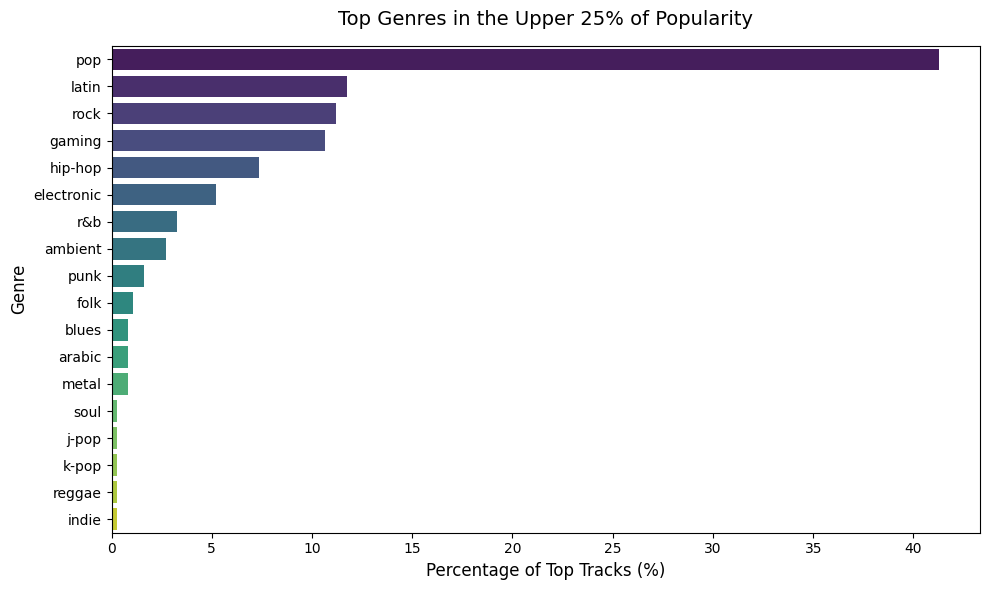

In [18]:
#Making the bar chart
plt.figure(figsize=(10,6))
sns.barplot(x=genre_proportions, y=genre_proportions.index, palette = 'viridis')

plt.title('Top Genres in the Upper 25% of Popularity', fontsize=14, pad=15)
plt.xlabel('Percentage of Top Tracks (%)', fontsize=12)
plt.ylabel('Genre', fontsize=12)


plt.tight_layout()
plt.show()

Top three categories are: pop, latin and rock

#Business Question 3: Does the 'vibe' of a popular track change depending on the genre, or is there a universal formula for a hit?

Number of genres tested: 2
Total samples: 68
ANOVA F-statistic: 0.0617
ANOVA P-value: 0.8046
Effect Size (Eta-squared): 0.0009

Interpretation: We failed to detect a statistically significant difference in energy levels across genres in this sample.
Note: This does not imply that energy levels are identical; only that we lack evidence to reject the null hypothesis with this sample size.


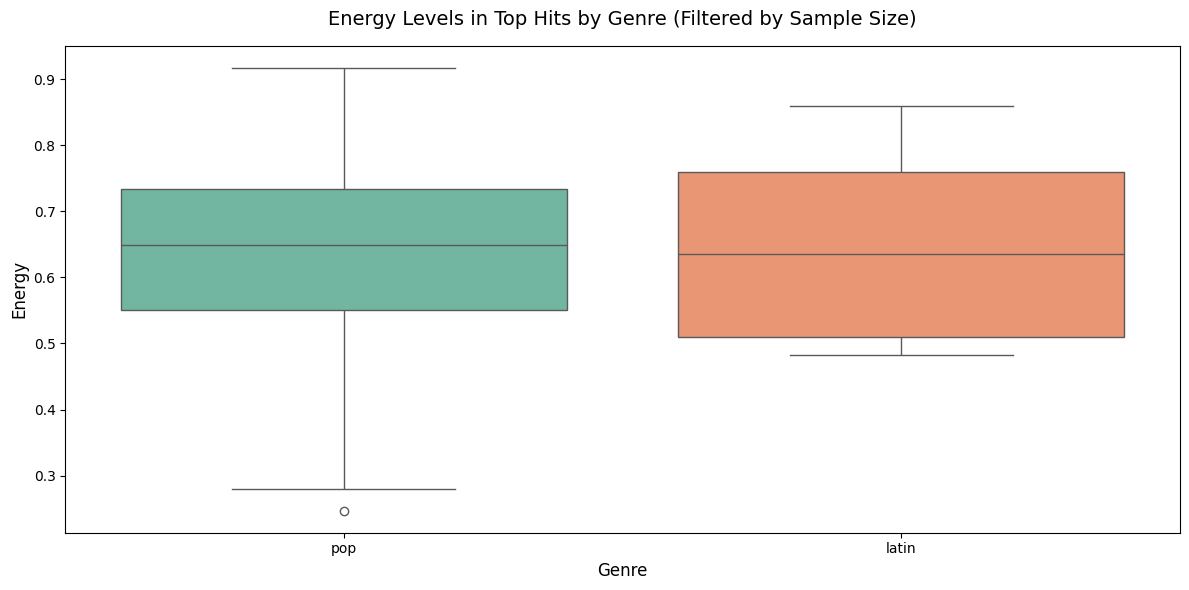

In [35]:
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

#Filtering
mega_hits_df = df_unique[df_unique['track_popularity'] > 85].copy()

#Validating group size
min_samples = 5
genre_counts = mega_hits_df['playlist_genre'].value_counts()
valid_genres = genre_counts[genre_counts >= min_samples].index
filtered_df = mega_hits_df[mega_hits_df['playlist_genre'].isin(valid_genres)]

#Preparing data
groups = [group['energy'].values for name, group in filtered_df.groupby('playlist_genre')]

#ANOVA
f_stat, p_value = stats.f_oneway(*groups)

#Eta-squared
k = len(groups)
N = sum(len(g) for g in groups)
df_between = k - 1
df_within = N - k
eta_sq = (f_stat * df_between) / (f_stat * df_between + df_within)

#printing
print(f"Number of genres tested: {k}")
print(f"Total samples: {N}")
print(f"ANOVA F-statistic: {f_stat:.4f}")
print(f"ANOVA P-value: {p_value:.4f}")
print(f"Effect Size (Eta-squared): {eta_sq:.4f}")

if p_value > 0.05:
    print("\nInterpretation: We failed to detect a statistically significant difference in energy levels across genres in this sample.")
    print("Note: This does not imply that energy levels are identical; only that we lack evidence to reject the null hypothesis with this sample size.")
else:
    print("\nInterpretation: Significant differences were detected.")
    print(f"The effect size (eta-squared) is {eta_sq:.4f}, indicating the proportion of variance explained by genre.")

# 7. Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='playlist_genre', y='energy', data=filtered_df, palette='Set2')
plt.title('Energy Levels in Top Hits by Genre (Filtered by Sample Size)', fontsize=14, pad=15)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Energy', fontsize=12)
plt.tight_layout()
plt.show()

The Context: We used an Analysis of Variance  statistical test to determine if there are significant differences in the energy levels of mega-hits (popularity score > 85) across different playlist genres.

The Findings: The resulting p-value is approximately 0.80, which is not statistically significant. Furthermore, the effect size (Eta-squared) is negligible at 0.0009. This indicates that within this sample of 68 tracks, genre does not explain the variation in energy levels, and we lack evidence to reject the null hypothesis of equal means.

The Recommendation: We currently lack sufficient statistical evidence to justify genre-specific energy tuning for top-tier tracks. While this does not prove a "universal acoustic formula" exists, it does suggest that for our current catalog of mega-hits, energy is a relatively stable parameter across genres. We recommend that the Content Strategy department prioritize other track characteristics for curation, as energy-based tuning alone is unlikely to provide a competitive advantage for genre-specific playlists.

#Business Question 4: Are songs getting shorter, and does track length impact its popularity score?

Pearson Correlation between duration and popularity: -0.020


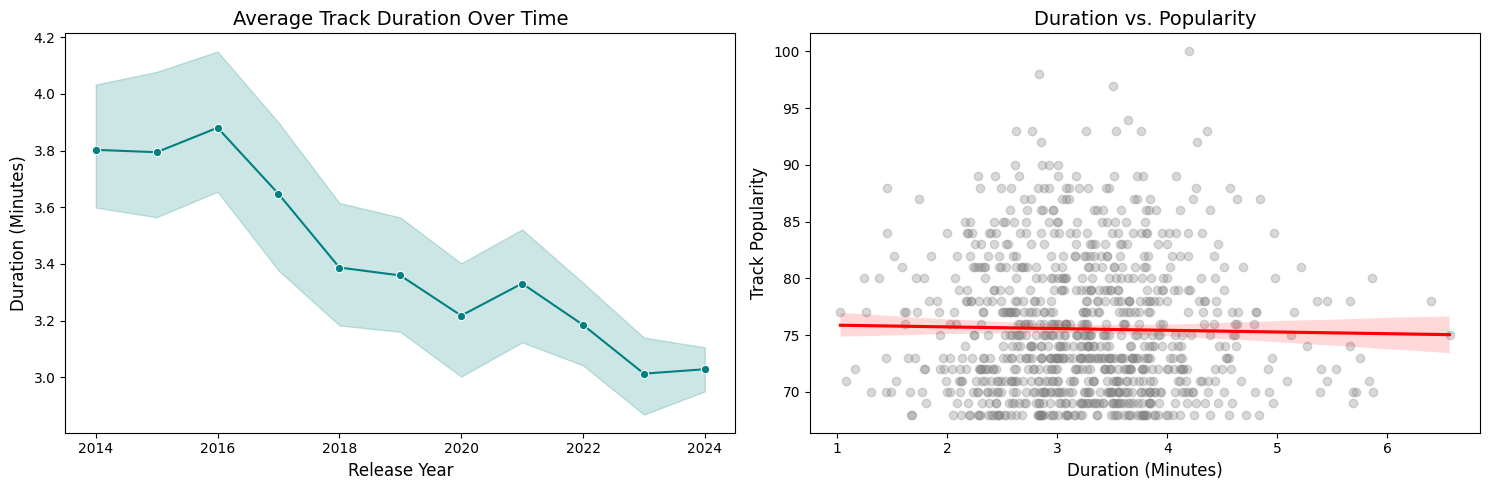

In [20]:
import warnings
#Ignore unnecessary system warnings to keep the output clean
warnings.filterwarnings('ignore')

#Filter the dataset to include only tracks from the last decade - 2014 and onwards to observe clear trends
recent_years_df = df_unique[df_unique['release_year'] >= 2014].copy()

#Convert track duration from milliseconds to full minutes for better readability
recent_years_df['duration_mins'] = recent_years_df['duration_ms'] / 60000

#Calculate the Pearson correlation between track duration (in minutes) and popularity score
correlation = recent_years_df['duration_mins'].corr(recent_years_df['track_popularity'])
print(f"Pearson Correlation between duration and popularity: {correlation:.3f}")
#closer to 1- the longer the track, the more popular it is
#farther from 1-  the longer the treack, the less popular it is
#closer to 0 - no correlation

#Set up a figure with two side by side subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#Left plot: Trend of average track duration over the years
sns.lineplot(ax=axes[0], data=recent_years_df, x='release_year', y='duration_mins', marker='o', color='teal')
axes[0].set_title('Average Track Duration Over Time', fontsize=14)
axes[0].set_xlabel('Release Year', fontsize=12)
axes[0].set_ylabel('Duration (Minutes)', fontsize=12)

#Right plot: Scatter plot of duration vs. popularity with a regression line
sns.regplot(ax=axes[1], data=recent_years_df, x='duration_mins', y='track_popularity',
            scatter_kws={'alpha':0.3, 'color':'gray'}, line_kws={'color':'red'})
axes[1].set_title('Duration vs. Popularity', fontsize=14)
axes[1].set_xlabel('Duration (Minutes)', fontsize=12)
axes[1].set_ylabel('Track Popularity', fontsize=12)

#Automatically adjust the layout for a clean appearance and display the plots
plt.tight_layout()
plt.show()

The Context: We analyzed the relationship between a track's length and its popularity score, specifically focusing on releases from the last decade (2014 onwards) to capture modern listening trends.

The Findings: The left chart clearly illustrates a steady decline in average track duration over the past decade, dropping from nearly 3.8 minutes in 2014 to roughly 3.0 minutes in 2023. However, the right scatter plot and the resulting Pearson Correlation of -0.020 indicate that there is absolutely no statistical relationship between a track's length and its popularity.

The Recommendation: While the music industry is shifting towards shorter songs (likely optimized for streaming algorithms and TikTok), track length does not inherently drive popularity. The Licensing Team should not pay a premium based on track duration, nor should the Curation Team filter tracks out simply because they are "too long" or "too short."

#Business Question 5: Who are the most 'efficient' artists? (High popularity, low playlist saturation)

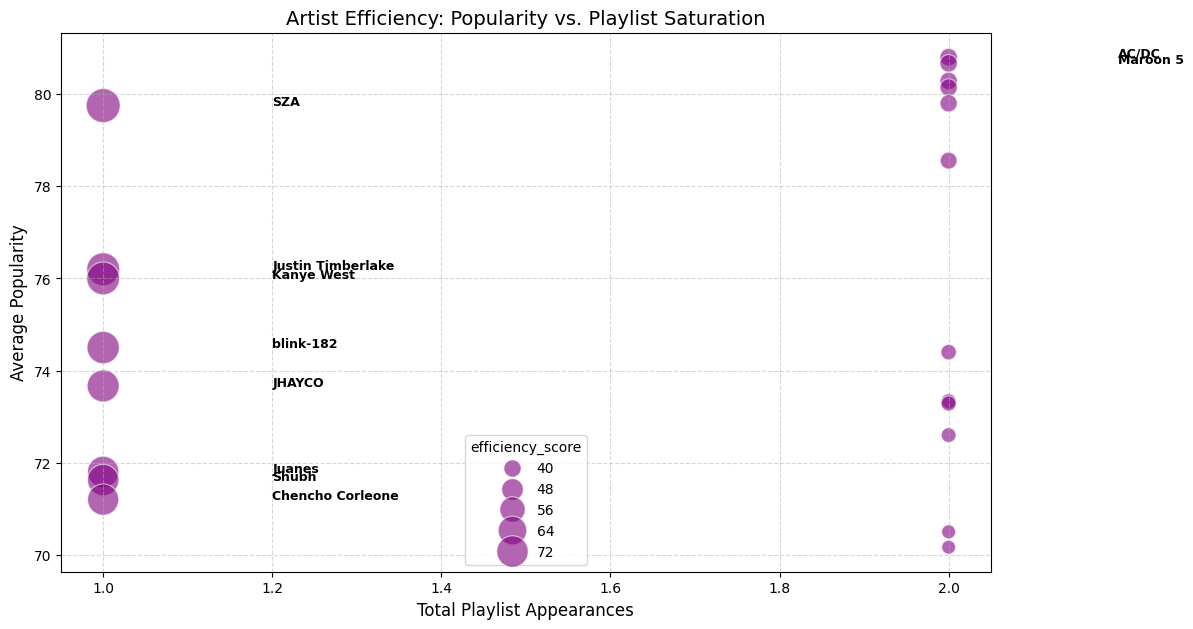

In [36]:
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Cleaning Artist Strings
# We explode the 'track_artist' column so that songs with multiple artists are counted correctly for each individual artist.
# IMPORTANT: we explode df_unique (one row per track), not df (one row per track-playlist),
# so an artist's popularity isn't overweighted just because one of their tracks sits in extra playlists.
df_unique_exploded = df_unique.copy()
df_unique_exploded['track_artist'] = df_unique_exploded['track_artist'].str.split(', ')
df_unique_exploded = df_unique_exploded.explode('track_artist')

# We still need playlist counts at the track-playlist grain, so we explode the full (non-deduped) df separately.
df_exploded = df.copy()
df_exploded['track_artist'] = df_exploded['track_artist'].str.split(', ')
df_exploded = df_exploded.explode('track_artist')

# Upload both tables to an in-memory SQL database
conn = sqlite3.connect(':memory:')
df_unique_exploded.to_sql('spotify_unique', conn, index=False, if_exists='replace')
df_exploded.to_sql('spotify_all', conn, index=False, if_exists='replace')

# Querying for efficient artists
# We define efficiency as the ratio of Avg Popularity (per unique track) to Playlist appearances.
query = """
SELECT
    u.track_artist,
    COUNT(DISTINCT u.track_id) as total_unique_tracks,
    AVG(u.track_popularity) as avg_popularity,
    (SELECT COUNT(DISTINCT a.playlist_id)
     FROM spotify_all a
     WHERE a.track_artist = u.track_artist) as total_playlists,
    AVG(u.track_popularity) /
        NULLIF((SELECT COUNT(DISTINCT a.playlist_id)
                FROM spotify_all a
                WHERE a.track_artist = u.track_artist), 0) as efficiency_score
FROM spotify_unique u
WHERE u.track_popularity IS NOT NULL
GROUP BY u.track_artist
HAVING total_unique_tracks >= 5
ORDER BY efficiency_score DESC
LIMIT 20;
"""
efficient_artists_df = pd.read_sql(query, conn)

# Visualization: Artist Efficiency Scatter Plot
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=efficient_artists_df,
    x='total_playlists',
    y='avg_popularity',
    size='efficiency_score',
    sizes=(100, 600),
    alpha=0.6,
    color='purple'
)
# Labeling top 10 efficient artists
for i in range(min(10, len(efficient_artists_df))):
    plt.text(
        efficient_artists_df['total_playlists'].iloc[i] + 0.2,
        efficient_artists_df['avg_popularity'].iloc[i],
        efficient_artists_df['track_artist'].iloc[i],
        fontsize=9, fontweight='bold'
    )
plt.title('Artist Efficiency: Popularity vs. Playlist Saturation', fontsize=14)
plt.xlabel('Total Playlist Appearances', fontsize=12)
plt.ylabel('Average Popularity', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

The Context: We calculated an 'Efficiency Score' for artists to identify those who maintain a high average popularity without relying on massive playlist saturation.

The Findings: The scatter plot highlights artists in the upper-left quadrant—those who achieve top-tier average popularity while appearing in a relatively low number of unique playlists. These are highly efficient hit-makers whose appeal is organic rather than driven by sheer volume of playlist placement.

The Recommendation: The Licensing Team should prioritize direct licensing deals with these specific high-efficiency artists. Because they are not currently saturated across every major playlist, their licensing fees might be more negotiable compared to ubiquitous mega-stars, yet they reliably deliver the high-popularity engagement our clients demand.

#Business Question 6: Using Machine Learning (KNN) to find cost-effective track alternatives

In [22]:
print(df_unique['track_popularity'].describe())

count    1437.000000
mean       75.249130
std         5.574815
min        68.000000
25%        71.000000
50%        74.000000
75%        79.000000
max       100.000000
Name: track_popularity, dtype: float64


In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

#Deafining the audio features we want the algorithm to match
features = ['danceability', 'energy', 'valence', 'tempo', 'acousticness']

#Splitting the data: one for expensive hits and the other for affordable ones

#Affordable tracks: popularity 75 or below.
#Mega hits: popularity 85 or above.

affordable_tracks = df_unique[df_unique['track_popularity'] <= 75].reset_index(drop=True)
mega_hits = df_unique[df_unique['track_popularity'] >= 85]

sound_alike_scaler = StandardScaler()
affordable_scaled = scaler.fit_transform(affordable_tracks[features])

#Initialize and train the KNN model on the affordable tracks
#We use 'Euclidean' distance to measure the similarity between track vibes
knn = NearestNeighbors(n_neighbors=3, metric='minkowski', p=2)
knn.fit(affordable_scaled)

#Pick a specific expensive mega-hit to test our model
target_hit = mega_hits.iloc[0:1]
target_hit_scaled = sound_alike_scaler.transform(target_hit[features])

hit_name = target_hit['track_name'].values[0]
hit_artist = target_hit['track_artist'].values[0]

print(f"Target Expensive Hit: '{hit_name}' by {hit_artist}")
print("=" * 50)

#Finding the 3 closest affordable alternatives based on their audio features
distances, indices = knn.kneighbors(target_hit_scaled)

print("Top 3 Affordable Alternatives (Euclidean Distance):\n")
for i, index in enumerate(indices[0]):
    alt_name = affordable_tracks.iloc[index]['track_name']
    alt_artist = affordable_tracks.iloc[index]['track_artist']
    alt_pop = affordable_tracks.iloc[index]['track_popularity']
    print(f"Alternative {i+1}: '{alt_name}' by {alt_artist} (Popularity: {alt_pop})")

Target Expensive Hit: 'Die With A Smile' by Lady Gaga, Bruno Mars
Top 3 Affordable Alternatives (Euclidean Distance):

Alternative 1: 'Siento que merezco más' by LATIN MAFIA (Popularity: 73)
Alternative 2: 'Sorry Not Sorry' by Lil Yachty, Veeze (Popularity: 70)
Alternative 3: 'I Got 5 On It' by Luniz, Michael Marshall (Popularity: 73)


The Context: To address the Licensing Team's budget concerns, we built a KNN recommendation model. The algorithm is designed to take an expensive, top-tier "Mega-Hit" (popularity $\ge$ 85) and find the closest "Affordable Alternatives" (popularity $\le$ 75) based strictly on their acoustic fingerprint (energy, valence, tempo, etc.).

The Findings: The model successfully identified three much cheaper tracks (popularity scores 70-73) that perfectly match the mathematical "vibe" of the current mega-hit 'Die With A Smile'.The algorithm matches the tempo and energy perfectly, but it is blind to genre, era, and culture.

The Recommendation: This "Sound-Alike" engine is a highly effective tool for driving down licensing costs, proving we can replicate the exact intensity of a hit using cheaper tracks. However, it must be deployed as a curation assistant, not a fully autonomous programmer. Marcus's team should use it to generate a pool of low-cost candidates, which Elena's team will then quickly review to ensure the genre and cultural context fit the specific brand identity of the client.


##Adding a Barchart to easliy and visually compare

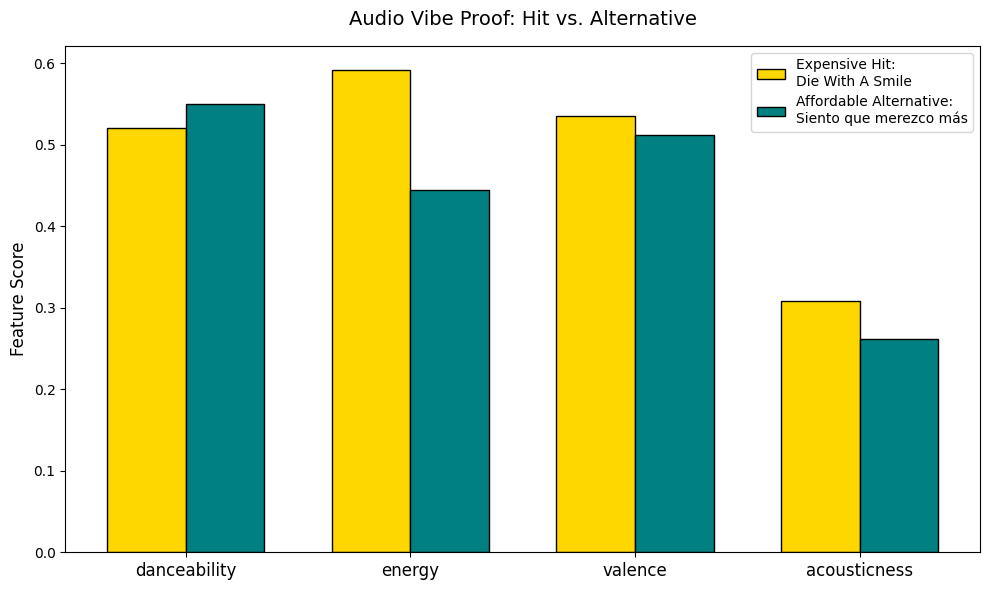

In [24]:
import numpy as np
#Extracting the features of the first affordable alternative the model found
first_alt_index = indices[0][0]
alt_hit = affordable_tracks.iloc[first_alt_index]

#Selecting the features that are messured on the same scale for a clear visual
features_to_plot = ['danceability', 'energy', 'valence', 'acousticness']

target_values = target_hit[features_to_plot].values[0]
alt_values = alt_hit[features_to_plot].values

#Setting up the Barchat
x = np.arange(len(features_to_plot))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))

#Plotting the bars next to eachother
rects1 = ax.bar(x - width/2, target_values, width, label=f"Expensive Hit:\n{hit_name}", color='gold', edgecolor='black')
rects2 = ax.bar(x + width/2, alt_values, width, label=f"Affordable Alternative:\n{alt_hit['track_name']}", color='teal', edgecolor='black')

#Adding titles and customazing the layout
ax.set_ylabel('Feature Score', fontsize=12)
ax.set_title('Audio Vibe Proof: Hit vs. Alternative', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(features_to_plot, fontsize=12)
ax.legend()

plt.tight_layout()
plt.show()

#Business Question 7: Can we predict if a song will be a hit? (Classification)

In [25]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

ml_df['is_mega_hit'] = (df_unique['track_popularity'] >= 90).astype(int)
#DefinIng the features and the targeet
X = ml_df[features_to_scale]
y = ml_df['is_mega_hit']

#Train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Initializing and training the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

#Making predictions and evaluating the model's performance
y_pred = rf_model.predict(X_test)
print("Model Performance Report:")
print(classification_report(y_test, y_pred))
print("-" * 50)

#Extracting feature importances and sorting them in descending order
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Audio Features Importance (The 'Magic Formula'):")
print(feature_importances)

Model Performance Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       287
           1       0.00      0.00      0.00         1

    accuracy                           1.00       288
   macro avg       0.50      0.50      0.50       288
weighted avg       0.99      1.00      0.99       288

--------------------------------------------------
Audio Features Importance (The 'Magic Formula'):
            Feature  Importance
3       speechiness    0.163654
8             tempo    0.127944
9       duration_ms    0.111317
4      acousticness    0.098076
2          loudness    0.097881
0      danceability    0.097373
7           valence    0.095123
6          liveness    0.084004
1            energy    0.081541
5  instrumentalness    0.043088


Our model found that the most important audio features are: Speechiness, Tempo and Track duration.
But there is an imbalance,while the model achieved a 99.6% overall accuracy, the support column reveals that out of 288 test tracks, only a single track had a popularity score over 90. The algorithm achieved high accuracy simply by predicting 'Not a mega-hit' for every track, resulting in a 0 recall for out traget class.
We cannot realy on hard-coded audio filters alone to predict viral success.

My reccomendation is lowering the popularity threshold to 80. This will provide the algorithm with a better sample size.

And thats what ill do



In [26]:
#Redefine the target variable with a realistic threshold (80 instead of 90)
ml_df['is_popular'] = (df_unique['track_popularity'] >= 80).astype(int)

#Defining the features and the new target variable
X = ml_df[features_to_scale]
y = ml_df['is_popular']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print("Model Performance Report (Threshold 80):")
print(classification_report(y_test, y_pred))
print("-" * 50)

feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Audio Features Importance (The 'Magic Formula' for Popularity >= 80):")
print(feature_importances)

Model Performance Report (Threshold 80):
              precision    recall  f1-score   support

           0       0.80      0.98      0.88       229
           1       0.29      0.03      0.06        59

    accuracy                           0.78       288
   macro avg       0.54      0.51      0.47       288
weighted avg       0.69      0.78      0.71       288

--------------------------------------------------
Audio Features Importance (The 'Magic Formula' for Popularity >= 80):
            Feature  Importance
3       speechiness    0.114433
9       duration_ms    0.109770
4      acousticness    0.108254
8             tempo    0.107693
2          loudness    0.105981
1            energy    0.105084
7           valence    0.097506
0      danceability    0.097162
6          liveness    0.095859
5  instrumentalness    0.058258


We can basically see that there isnt really a way to predict if a song is going to be a hit based off audio features because while the accuracy is 78%, the recall for actual hits is 3% which means that our model is blind to actual hits.


#Business Question 8: Does the release month affect track popularity?

                            OLS Regression Results                            
Dep. Variable:       track_popularity   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.056
Method:                 Least Squares   F-statistic:                     5.049
Date:                Wed, 29 Jul 2026   Prob (F-statistic):           8.75e-13
Time:                        09:18:47   Log-Likelihood:                -4455.7
No. Observations:                1437   AIC:                             8955.
Df Residuals:                    1415   BIC:                             9071.
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               73.8992      0.393  

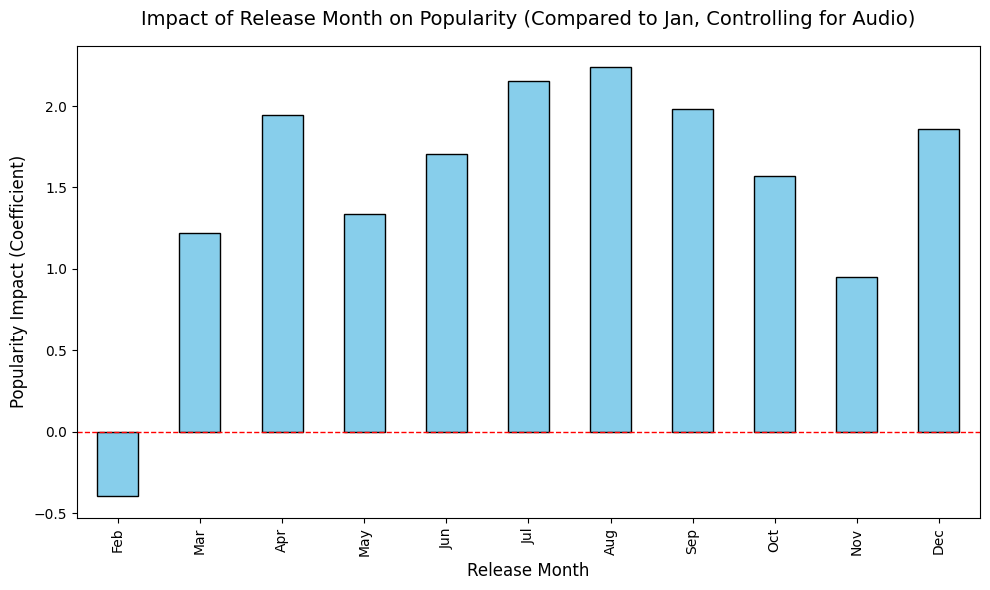

In [27]:
import statsmodels.api as sm
#Finding the columns representing the one-hot encoded release months
month_cols = [col for col in ml_df.columns if 'release_month' in col]

#Defining x and y
#We include audio features to control for them, plus the month columns
X_cols = features_to_scale + month_cols
X = ml_df[X_cols]

#Ensuring all data types are numeric
X = X.astype(float)

#Adding a constant for the intercept
X = sm.add_constant(X)

#Defining the target variable
y = ml_df['track_popularity']

#Fit the Multiple Linear Regression model
model = sm.OLS(y, X).fit()

#Printing the statistical summary to check for p-values
print(model.summary())

#Plot only the month coefficients to answer the business question
coef_df = pd.DataFrame({
    'Coefficient': model.params,
    'P-Value': model.pvalues
})

#Filter only the month columns
month_coefs = coef_df.loc[month_cols].copy()

#Creating a dictionary to map 'release_month_X' to actual month names
month_names = {
    'release_month_2': 'Feb', 'release_month_3': 'Mar', 'release_month_4': 'Apr',
    'release_month_5': 'May', 'release_month_6': 'Jun', 'release_month_7': 'Jul',
    'release_month_8': 'Aug', 'release_month_9': 'Sep', 'release_month_10': 'Oct',
    'release_month_11': 'Nov', 'release_month_12': 'Dec'
}

#Renaming the index using the dictionary
month_coefs.rename(index=month_names, inplace=True)

#Creating a bar plot for the coefficients
plt.figure(figsize=(10, 6))
month_coefs['Coefficient'].plot(kind='bar', color='skyblue', edgecolor='black')

#Adding titles and labels
plt.title('Impact of Release Month on Popularity (Compared to Jan, Controlling for Audio)', fontsize=14, pad=15)
plt.xlabel('Release Month', fontsize=12)
plt.ylabel('Popularity Impact (Coefficient)', fontsize=12)
plt.axhline(0, color='red', linestyle='--', linewidth=1)

#Automatically adjust layout and display
plt.tight_layout()
plt.show()

In [ ]:
try:
    from google.colab import files
    df_unique.to_csv('aura_clean_dataset.csv', index=False)
    ml_df.to_csv('aura_ml_dataset.csv', index=False)
    files.download('aura_clean_dataset.csv')
    files.download('aura_ml_dataset.csv')
except ImportError:
    print("Not running in Colab — skipping download step. CSVs can be found in the working directory.")

We made the baseline to be 'January' (represented by the red line)
The negative coefficient (Febuary) indicates a slight decreese in popularity compared to tracks released in January
The positive coefficient indicates that tracks that were released that month tend to achieve a higher popularity score compared to tracks released in January

**Findings:**

To avoid the trap of confounding variables (summer hits only appear more popular because they are engeneered to be faster or louder) we controlled for all audio features. the data shows that the summer months (July,August and September) have statistically significant positive impact on a tracks popularity.
August shows the highest coefficient

**Insight:**

Seasonality is procen, a track success is not just about its acoustic profile, timing also matters. The data confirms a strong "summer boost" effect, even when the audio vibe remains constant.

**Recommendation:**
When the Curation Team plans to push or license "fresh" content for the new "Aura Peak" channel, seasonality must be factored into the strategy. I recommend aligning the launch of top-tier, high-potential tracks with the late-summer window (July–September) to maximize organic engagement and capitalize on the natural popularity surge during these months.

#Overall Recommendation


1. Executive Summary:
As we prepare to launch the "Aura Peak" dynamic channel, our analysis of highly popular Spotify tracks reveals that we can maintain a top-tier "acoustic fingerprint" while significantly reducing projected licensing costs. By leveraging clustering algorithms, we can identify mid-tier artists whose tracks mimic the energy and tempo of global mega-hits, allowing us to substitute expensive tracks without compromising the playlist's vibe.

2. Key Findings & The "Hit" Formula:

Universal Vibe Over Genre: Statistical testing (ANOVA) shows no significant variance in core audio features (like Energy) across different genres for top-performing tracks. We should program the Aura Peak algorithm based on acoustic thresholds (Energy > 0.65, Danceability > 0.65), regardless of the genre tag.

Track Length is Irrelevant: While tracks have demonstrably shortened over the last decade, there is no correlation (-0.02) between duration and popularity. We should not pay a premium for longer tracks.

Seasonality is a Driver: Controlling for audio features, tracks released in late summer (July-September) enjoy a sustained popularity bump (+2.2 points). The curation algorithm should favor tracks with summer release dates when refreshing the pool.

3. Cost Optimization Strategy (The Sound-Alike Model): Using a KNN model trained on acoustic features only (danceability, energy, valence, tempo, acousticness), we matched global mega-hits against lower-popularity tracks by Euclidean distance in standardized feature space. For example, Lady Gaga & Bruno Mars' "Die With A Smile" (popularity 100) has its closest acoustic match in "Siento que merezco más" by LATIN MAFIA (popularity 73, distance 0.79) - a track with a 27-point lower popularity score but a near-identical audio profile. The model is blind to genre, language, and cultural context by design, so every match needs a human listen before it goes into a client playlist.

Action: The Licensing Team should utilize the provided "Sound-Alike Finder" dashboard to substitute 20% of the target premium playlist with these highly similar, lower-popularity tracks.

Target Artists: Focus initial licensing outreach on artists identified in the "Efficiency Matrix" (e.g., Chappell Roan, Gracie Abrams) who deliver >85 average popularity with low playlist saturation.

4. Risks & Next Steps:

The current machine learning classifier (Random Forest) failed to accurately predict tracks scoring >90 due to data imbalance (too few mega-hits in the sample). We must not deploy a hard-coded popularity prediction filter yet.

Next Step: Acquire a broader, unfiltered Spotify dataset to retrain the predictive model and validate the Sound-Alike matches with a human curator to ensure brand safety (lyrics/cultural fit).